In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
diabetes_df = pd.read_csv('diabetes.csv')
heart_df = pd.read_csv('heart.csv')
stroke_df = pd.read_csv('stroke.csv')
liver_df = pd.read_csv('liver.csv')

In [3]:
# Remove unnecessary columns
diabetes_df.drop(columns=[c for c in ['Insulin','SkinThickness','DiabetesPedigreeFunction'] if c in diabetes_df.columns], inplace=True)
stroke_df.drop(columns=[c for c in ['id'] if c in stroke_df.columns], inplace=True)
heart_df.drop(columns=[c for c in ['ca','thal','slope'] if c in heart_df.columns], inplace=True)

# Fill missing values
for df in [diabetes_df, heart_df, stroke_df, liver_df]:
    df.fillna(df.median(numeric_only=True), inplace=True)
    for col in df.select_dtypes(include='object').columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_19316\56733719.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:
C:\Users\DELL\AppData\Local\Temp\ipykernel_19316\56733719.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[

In [4]:
def perform_eda(df, target, title):

    print(f"\n📊 EDA Dashboard for {title}")

    numeric_cols = df.select_dtypes(include=np.number).columns

    # Create grid (3 rows × 2 cols)
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    fig.suptitle(f"{title} - EDA Dashboard", fontsize=16)

    # ---------------- Histogram ----------------
    if len(numeric_cols) > 0:
        sns.histplot(df[numeric_cols[0]], kde=True, ax=axes[0,0], color='skyblue')
        axes[0,0].set_title("Histogram")

    # ---------------- Target Distribution ----------------
    sns.countplot(x=target, data=df, ax=axes[0,1], palette="Set2")
    axes[0,1].set_title("Target Distribution")

    # ---------------- Box Plot ----------------
    if len(numeric_cols) > 0:
        sns.boxplot(x=target, y=numeric_cols[0], data=df, ax=axes[1,0], palette="Set2")
        axes[1,0].set_title("Box Plot")

    # ---------------- Violin Plot ----------------
    if len(numeric_cols) > 0:
        sns.violinplot(x=target, y=numeric_cols[0], data=df, ax=axes[1,1], palette="Set2")
        axes[1,1].set_title("Violin Plot")

    # ---------------- Scatter Plot ----------------
    if len(numeric_cols) > 1:
        sns.scatterplot(
            x=numeric_cols[0],
            y=numeric_cols[1],
            hue=target,
            data=df,
            ax=axes[2,0]
        )
        axes[2,0].set_title("Scatter Plot")

    # ---------------- Pie Chart ----------------
    pie_data = df[target].value_counts()
    axes[2,1].pie(
        pie_data,
        labels=pie_data.index,
        autopct='%1.1f%%',
        colors=['#66b3ff','#ff9999']
    )
    axes[2,1].set_title("Class Distribution")

    plt.tight_layout()
    plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_19316\2199613403.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target, data=df, ax=axes[0,1], palette="Set2")



📊 EDA Dashboard for Diabetes


C:\Users\DELL\AppData\Local\Temp\ipykernel_19316\2199613403.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=numeric_cols[0], data=df, ax=axes[1,0], palette="Set2")
C:\Users\DELL\AppData\Local\Temp\ipykernel_19316\2199613403.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target, y=numeric_cols[0], data=df, ax=axes[1,1], palette="Set2")


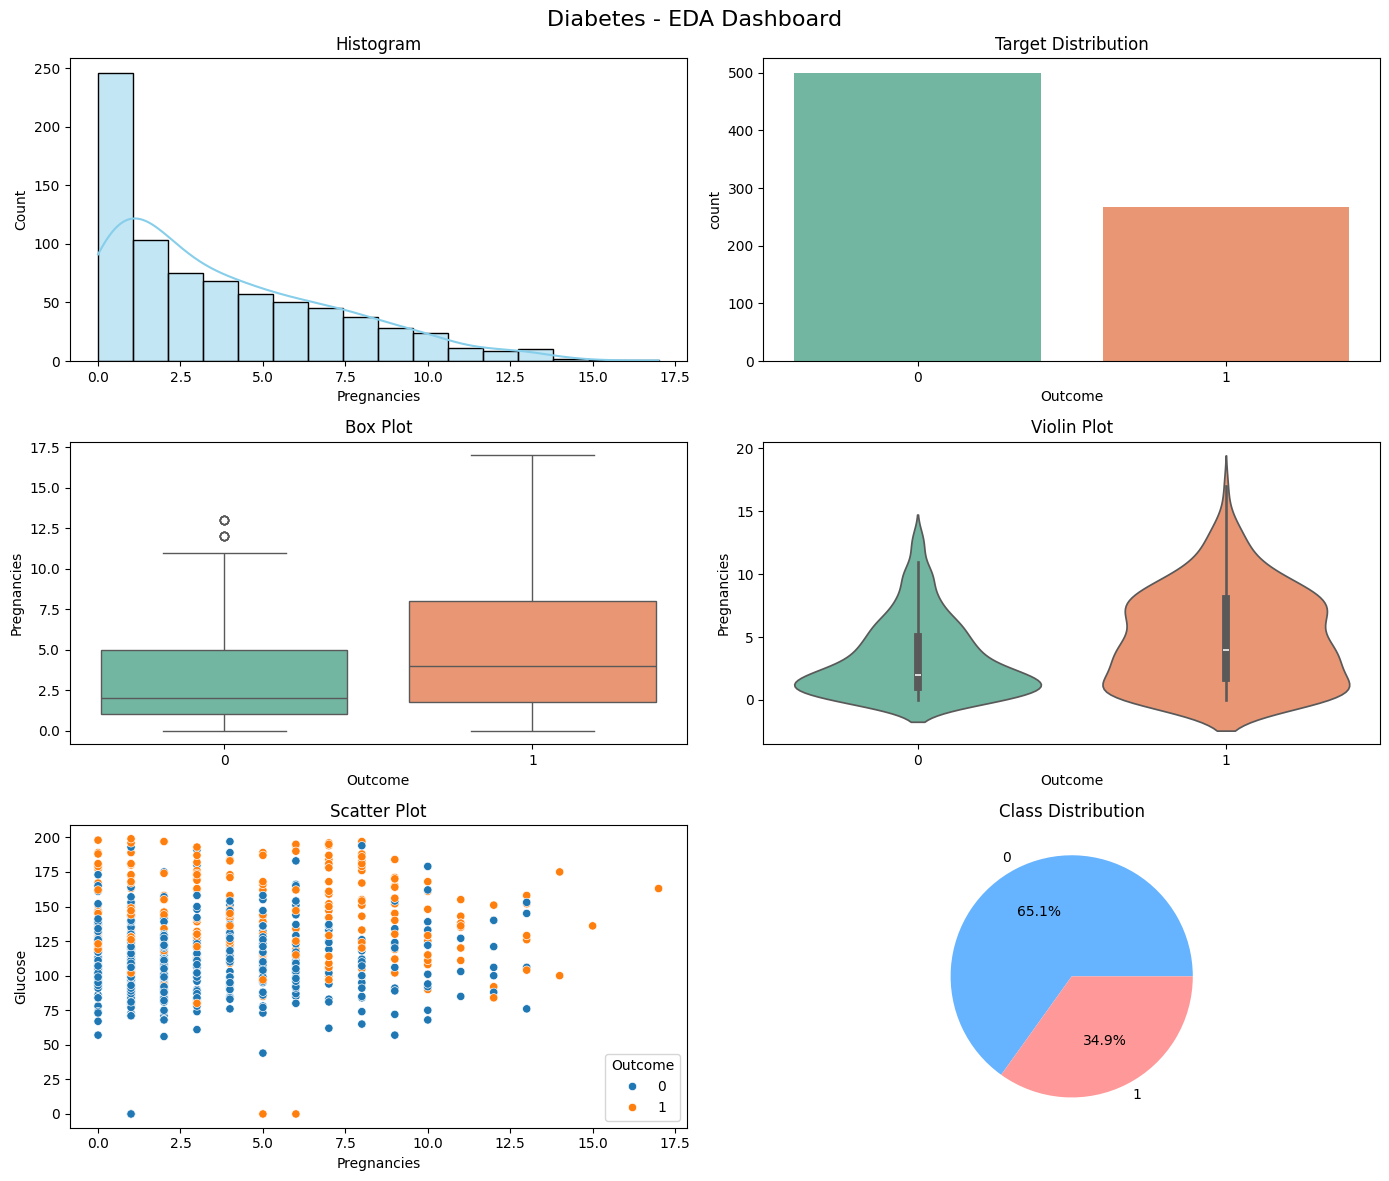


📊 EDA Dashboard for Heart


C:\Users\DELL\AppData\Local\Temp\ipykernel_19316\2199613403.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target, data=df, ax=axes[0,1], palette="Set2")
C:\Users\DELL\AppData\Local\Temp\ipykernel_19316\2199613403.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=numeric_cols[0], data=df, ax=axes[1,0], palette="Set2")
C:\Users\DELL\AppData\Local\Temp\ipykernel_19316\2199613403.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target, y=numeric_cols[0], data=df, ax=axes[1,1], palette="Set2")


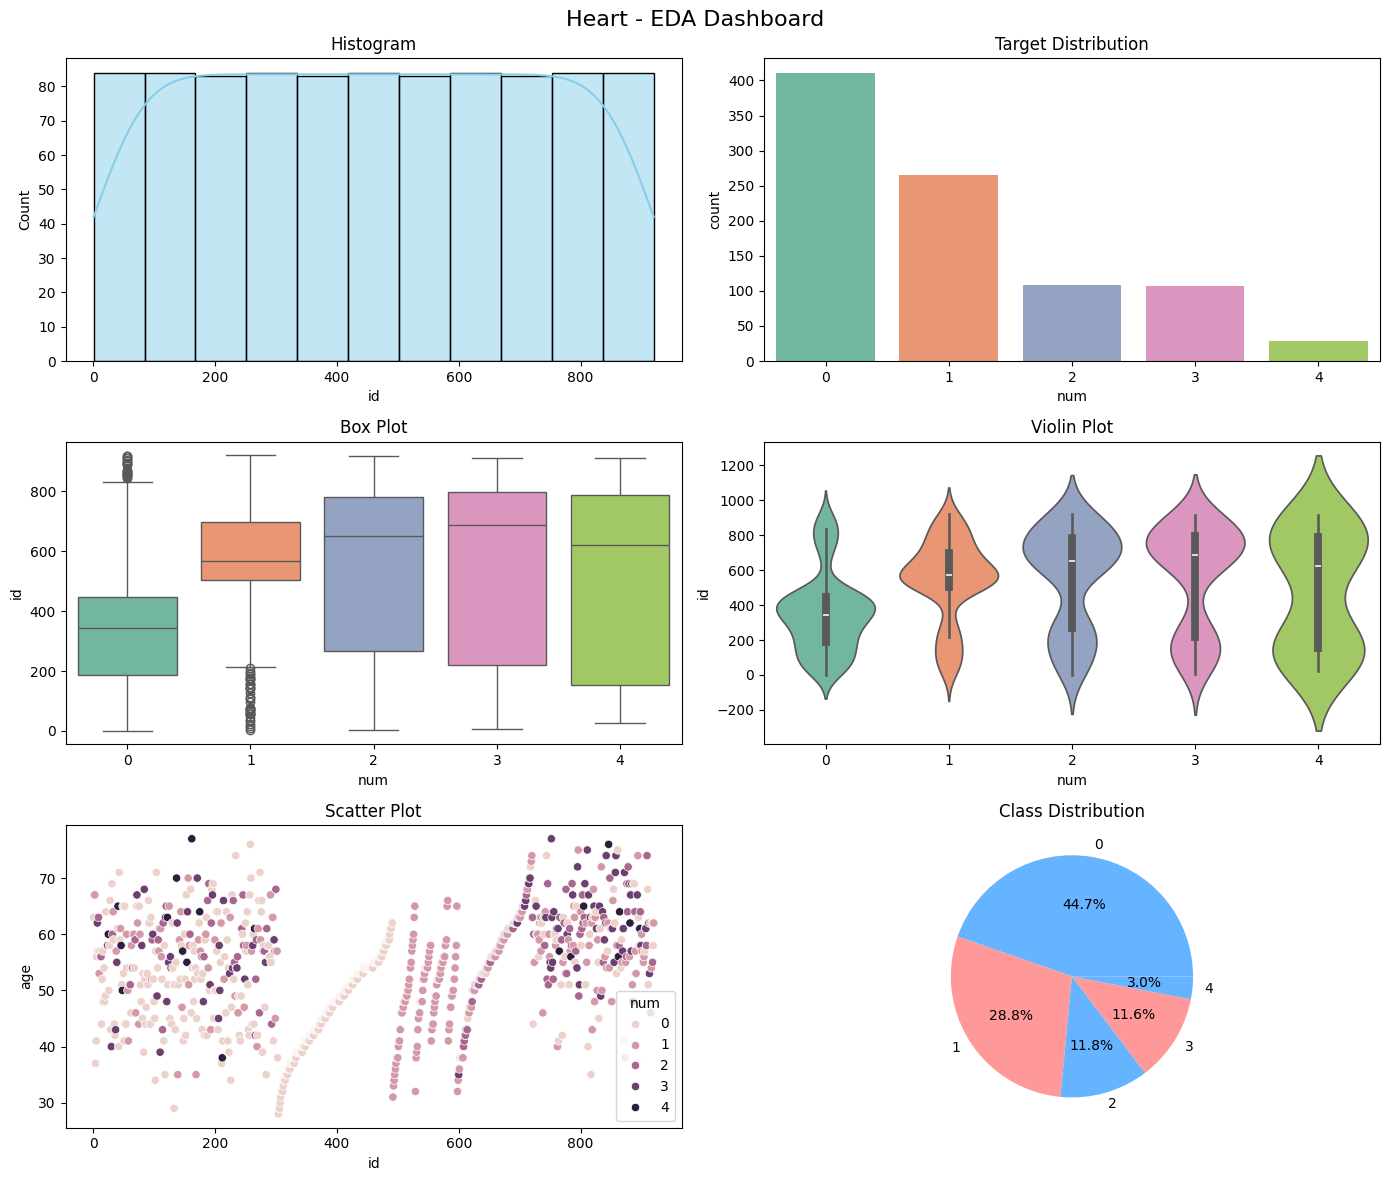


📊 EDA Dashboard for Stroke


C:\Users\DELL\AppData\Local\Temp\ipykernel_19316\2199613403.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target, data=df, ax=axes[0,1], palette="Set2")
C:\Users\DELL\AppData\Local\Temp\ipykernel_19316\2199613403.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=numeric_cols[0], data=df, ax=axes[1,0], palette="Set2")
C:\Users\DELL\AppData\Local\Temp\ipykernel_19316\2199613403.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target, y=numeric_cols[0], data=df, ax=axes[1,1], palette="Set2")


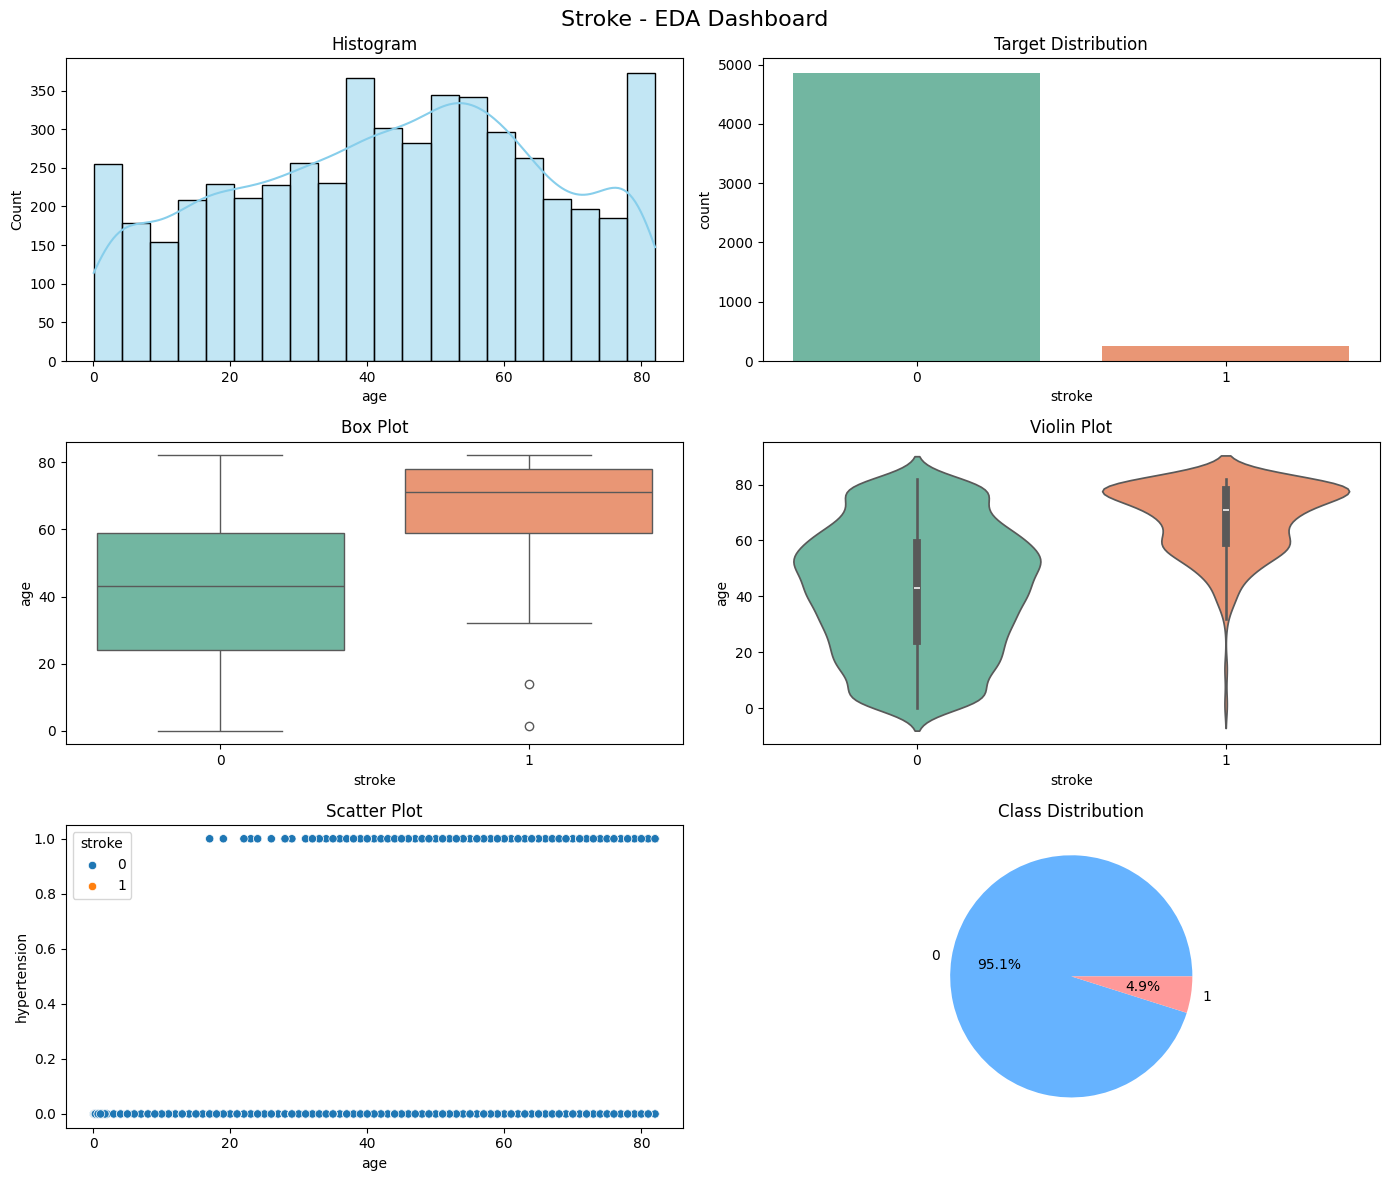


📊 EDA Dashboard for Liver


C:\Users\DELL\AppData\Local\Temp\ipykernel_19316\2199613403.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target, data=df, ax=axes[0,1], palette="Set2")
C:\Users\DELL\AppData\Local\Temp\ipykernel_19316\2199613403.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=numeric_cols[0], data=df, ax=axes[1,0], palette="Set2")
C:\Users\DELL\AppData\Local\Temp\ipykernel_19316\2199613403.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target, y=numeric_cols[0], data=df, ax=axes[1,1], palette="Set2")


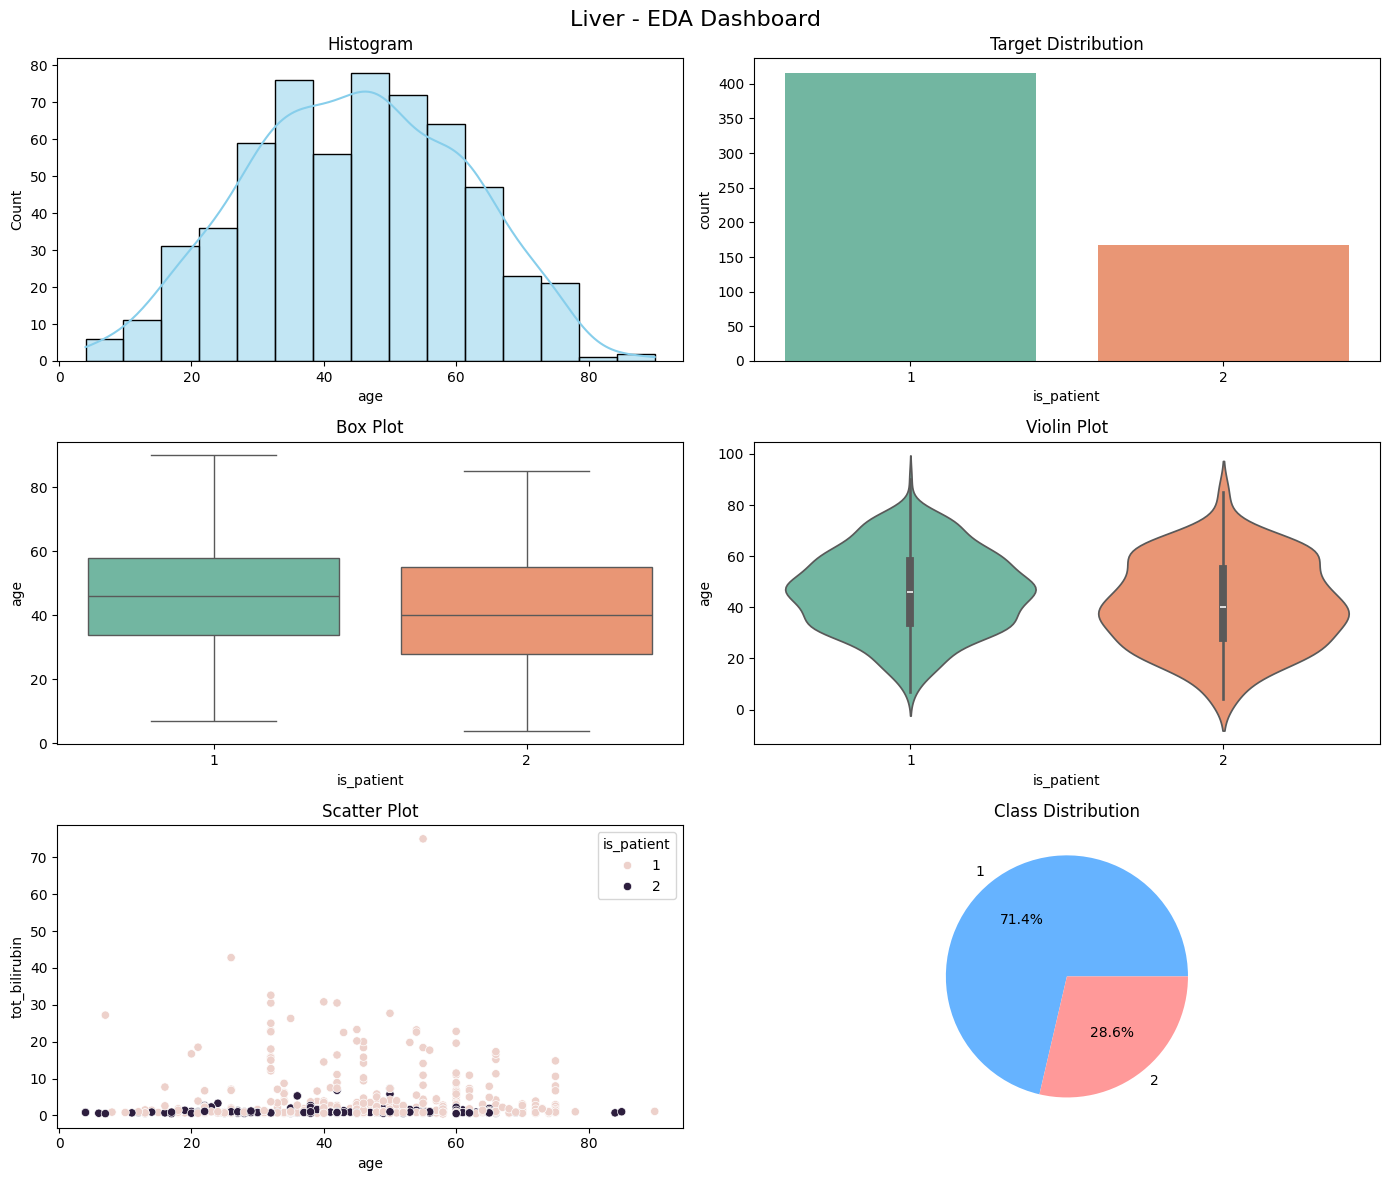

In [5]:
perform_eda(diabetes_df, 'Outcome', "Diabetes")
perform_eda(heart_df, 'target' if 'target' in heart_df.columns else 'num', "Heart")
perform_eda(stroke_df, 'stroke', "Stroke")
perform_eda(liver_df, 'is_patient', "Liver")

In [6]:
def train_model(df, target):
    from sklearn.linear_model import LinearRegression

    X = pd.get_dummies(df.drop(target, axis=1), drop_first=True)
    y = df[target]

    X = X.fillna(0)
    y = y.fillna(0)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )

    # -------- Gradient Boosting (MAIN MODEL) --------
    model = GradientBoostingClassifier()
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    print("\nGradient Boosting Accuracy:", accuracy_score(y_test, preds))


    # -------- Linear Regression (FOR COMPARISON) --------
    lin_model = LinearRegression()
    lin_model.fit(X_train, y_train)

    lin_preds = lin_model.predict(X_test)
    lin_preds = (lin_preds > 0.5).astype(int)

    print("Linear Regression Accuracy:", accuracy_score(y_test, lin_preds))

    return model, scaler, X.columns

In [7]:
d_model, d_scaler, d_cols = train_model(diabetes_df, 'Outcome')

if 'target' in heart_df.columns:
    h_model, h_scaler, h_cols = train_model(heart_df, 'target')
else:
    h_model, h_scaler, h_cols = train_model(heart_df, 'num')

s_model, s_scaler, s_cols = train_model(stroke_df, 'stroke')
l_model, l_scaler, l_cols = train_model(liver_df, 'is_patient')


Gradient Boosting Accuracy: 0.7597402597402597
Linear Regression Accuracy: 0.7272727272727273

Gradient Boosting Accuracy: 0.5760869565217391
Linear Regression Accuracy: 0.5489130434782609

Gradient Boosting Accuracy: 0.9403131115459883
Linear Regression Accuracy: 0.9393346379647749

Gradient Boosting Accuracy: 0.717948717948718
Linear Regression Accuracy: 0.7435897435897436


In [8]:
def predict_risk(model, scaler, columns, input_data):
    df = pd.DataFrame([input_data])
    df = pd.get_dummies(df)
    df = df.reindex(columns=columns, fill_value=0)

    df_scaled = scaler.transform(df)
    prob = model.predict_proba(df_scaled)[0][1]
    return prob

In [9]:
def interpret_risk(prob):
    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.6:
        return "Moderate Risk"
    else:
        return "High Risk"

In [10]:
def show_menu():
    print("\nSelect diseases to check:")
    print("1. Diabetes")
    print("2. Heart Disease")
    print("3. Stroke")
    print("4. Liver Disease")
    print("5. All")

    choices = input(
        "\nEnter your choice:\n"
        "1 = Diabetes | 2 = Heart | 3 = Stroke | 4 = Liver | 5 = All\n"
        "Example: 1 3 → Diabetes + Stroke\n"
        "Your choice: "
    )

    return choices.split()

def get_user_info():
    name = input("Enter your Name: ")

    gender = input("Gender (Male/Female): ").strip().lower()

    # 🔥 SAFE AGE INPUT
    while True:
        age_input = input("Age: ").strip()
        if age_input.isdigit():
            age = int(age_input)
            break
        else:
            print("⚠ Please enter a valid numeric age!")

    print(f"\nWelcome {name.title()}! 😊")

    return {
        "name": name,
        "gender": gender,
        "age": age
    }

#DIABETES
def get_diabetes_input(user):
    print(f"\nHello {user['name'].title()}!")

    if user['gender'] == "female":
        print("Kindly enter details to check Diabetes 😊")
        pregnancies = int(input("Pregnancies: "))
    else:
        print("Pregnancies not applicable → set to 0")
        pregnancies = 0

    return {
        'Pregnancies': pregnancies,
        'Glucose': float(input("Glucose: ")),
        'BloodPressure': float(input("BP: ")),
        'BMI': float(input("BMI: ")),
        'Age': user['age']   # 🔥 reused
    }

#HEART DISEASE
def get_heart_input(user):
    print(f"\nHello {user['name'].title()}!")

    return {
        'age': user['age'],  # 🔥 reused
        'sex': 1 if user['gender'] == "male" else 0,
        'cp': int(input("Chest Pain (0-3): ")),
        'chol': float(input("Cholesterol: ")),
        'thalach': float(input("Max Heart Rate: ")),
        'exang': int(input("Exercise Angina (1/0): "))
    }

#HEART STROKE
def get_stroke_input(user):
    print(f"\nHello {user['name'].title()}!")

    return {
        'age': float(user['age']),
        'hypertension': int(input("Hypertension (1/0): ")),
        'heart_disease': int(input("Heart Disease (1/0): ")),
        'avg_glucose_level': float(input("Glucose Level: ")),
        'bmi': float(input("BMI: ")),
        'smoking_status': input("Smoking (never/former/current): ")
    }

#LIVER DISEASE
def get_liver_input(user):
    print(f"\nHello {user['name'].title()}!")

    return {
        'age': user['age'],
        'gender': user['gender'].title(),
        'tot_bilirubin': float(input("Total Bilirubin: ")),
        'alkphos': float(input("Alkaline Phosphotase: ")),
        'sgpt': float(input("SGPT: ")),
        'sgot': float(input("SGOT: "))
    }

In [ ]:
print("\n Personalized Health Risk Prediction System\n")

user = get_user_info()
choices = show_menu()

report = {}

# ------------------ Diabetes ------------------
if "1" in choices or "5" in choices:
    print("\nDiabetes")
    d_input = get_diabetes_input(user)
    d_prob = predict_risk(d_model, d_scaler, d_cols, d_input)
    report["Diabetes"] = (round(d_prob*100,2), interpret_risk(d_prob))

# ------------------ Heart ------------------
if "2" in choices or "5" in choices:
    print("\nHeart Disease")
    h_input = get_heart_input(user)
    h_prob = predict_risk(h_model, h_scaler, h_cols, h_input)
    report["Heart Disease"] = (round(h_prob*100,2), interpret_risk(h_prob))

# ------------------ Stroke ------------------
if "3" in choices or "5" in choices:
    print("\nStroke")
    s_input = get_stroke_input(user)
    s_prob = predict_risk(s_model, s_scaler, s_cols, s_input)
    report["Stroke"] = (round(s_prob*100,2), interpret_risk(s_prob))

# ------------------ Liver ------------------
if "4" in choices or "5" in choices:
    print("\nLiver Disease")
    l_input = get_liver_input(user)
    l_prob = predict_risk(l_model, l_scaler, l_cols, l_input)
    report["Liver Disease"] = (round(l_prob*100,2), interpret_risk(l_prob))


# ================= REPORT =================
print("\nHere is your personalized health risk report based on the information you provided. Please consult a healthcare professional for a comprehensive evaluation and advice. 🌟")
print(f"\nName   : {user['name'].title()}")
print(f"Gender : {user['gender'].title()}")
print(f"Age    : {user['age']}")

for disease, (prob, risk) in report.items():
    print(f"{disease}: {prob}% ({risk})")

print("\nThank You 😊,  Stay Healthy!")


 Personalized Health Risk Prediction System

